
K = 1
Accuracy : 0.8497
Precision: 0.8527108904515474
Recall   : 0.8497
F1 Score : 0.8503492525016987

K = 3
Accuracy : 0.8541
Precision: 0.8575414622679564
Recall   : 0.8541
F1 Score : 0.8539002124666113

K = 5
Accuracy : 0.8554
Precision: 0.8578152450755355
Recall   : 0.8554
F1 Score : 0.8546439722018906

K = 7
Accuracy : 0.854
Precision: 0.8570274817044016
Recall   : 0.854
F1 Score : 0.8534427202406818

K = 9
Accuracy : 0.8519
Precision: 0.8552816069950483
Recall   : 0.8519
F1 Score : 0.8513176586275853

Results Summary
   K  Accuracy  Precision  Recall  F1 Score
0  1    0.8497   0.852711  0.8497  0.850349
1  3    0.8541   0.857541  0.8541  0.853900
2  5    0.8554   0.857815  0.8554  0.854644
3  7    0.8540   0.857027  0.8540  0.853443
4  9    0.8519   0.855282  0.8519  0.851318


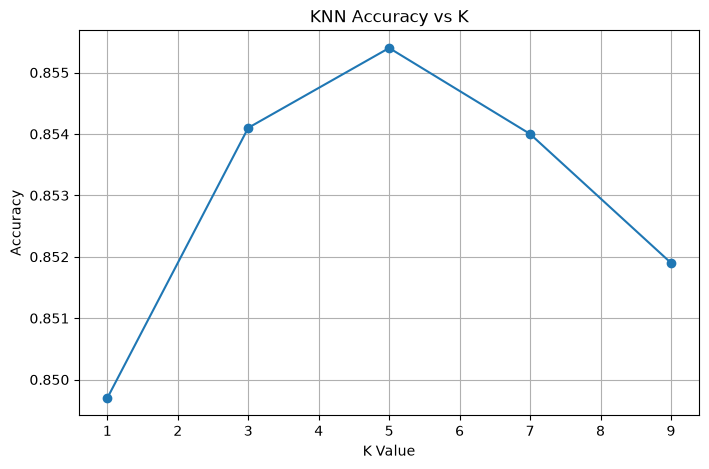

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("ASWIN PV-15")
# Load Fashion MNIST Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Preprocessing
# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images
X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

# Experiment with Different K Values
k_values = [1, 3,5,7,9]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train the model
    knn.fit(X_train, y_train)

    # Make predictions
    y_pred = knn.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # Store results
    results.append([
        k,
        accuracy,
        precision,
        recall,
        f1
    ])

    # Display results for each K
    print(f"\nK = {k}")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)


# Results Table
results_df = pd.DataFrame(
    results,
    columns=[
        'K',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

print("\nResults Summary")
print(results_df)


# Accuracy Plot
plt.figure(figsize=(8, 5))

plt.plot(
    results_df['K'],
    results_df['Accuracy'],
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.grid(True)
plt.show()

